In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_path = '/content/drive/MyDrive/Marathon/data/'

# Librairie


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

#!pip install odfpy


In [57]:
fashion = pd.read_excel(data_path+"data_fashion.ods",engine = "odf")

In [58]:
fashion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   product_id          660 non-null    int64         
 1   product_name        660 non-null    object        
 2   gender              660 non-null    object        
 3   category            660 non-null    object        
 4   pattern             660 non-null    object        
 5   color               660 non-null    object        
 6   age_group           660 non-null    object        
 7   season              660 non-null    object        
 8   price               660 non-null    float64       
 9   material            660 non-null    object        
 10  sales_count         660 non-null    int64         
 11  reviews_count       660 non-null    int64         
 12  average_rating      660 non-null    float64       
 13  out_of_stock_times  660 non-null    int64         

In [35]:
fashion.describe()

,product_id,price,sales_count,reviews_count,average_rating,out_of_stock_times,discount,last_stock_date,wish_list_count,month_of_sale,year_of_sale
count,660.000000,660.000000,660.00000,660.000000,660.000000,660.000000,660.000000,660,660.000000,660.000000,660.000000
mean,1330.500000,84.967939,265.55303,62.156061,4.016212,3.534848,0.103333,2020-06-30 13:16:21.818181888,151.683333,6.500000,2020.000000
min,1001.000000,20.250000,50.00000,20.000000,3.000000,1.000000,0.000000,2018-01-01 00:00:00,50.000000,1.000000,2018.000000
25%,1165.750000,53.197500,149.00000,42.000000,3.600000,2.000000,0.050000,2019-03-30 06:00:00,99.000000,3.750000,2019.000000
50%,1330.500000,82.040000,257.00000,63.000000,4.000000,4.000000,0.100000,2020-06-30 00:00:00,151.000000,6.500000,2020.000000
75%,1495.250000,117.770000,378.50000,83.250000,4.500000,5.000000,0.150000,2021-09-29 18:00:00,203.000000,9.250000,2021.000000
max,1660.000000,149.930000,500.00000,100.000000,5.000000,6.000000,0.200000,2022-12-26 00:00:00,250.000000,12.000000,2022.000000
std,190.669872,37.622893,132.32956,23.564812,0.550895,1.705209,0.069984,NaN,57.430499,3.454671,1.415286


In [59]:
table = pd.crosstab(fashion['color'],fashion['gender'])

In [61]:
stat, pvalue, dof, expected = chi2_contingency(table)

In [62]:
print("stat",stat)
print("pvalue",pvalue)
print("dof",dof)
print("expected",expected)

stat 3.212431668162546
pvalue 0.9876099574829476
dof 11
expected [[68.20606061 67.79393939]
 [14.04242424 13.95757576]
 [66.70151515 66.29848485]
 [ 7.52272727  7.47727273]
 [ 9.52878788  9.47121212]
 [ 7.02121212  6.97878788]
 [13.54090909 13.45909091]
 [12.03636364 11.96363636]
 [24.57424242 24.42575758]
 [10.03030303  9.96969697]
 [87.26363636 86.73636364]
 [10.53181818 10.46818182]]


In [60]:
table

gender,Female,Male
color,,
Beige,74,62
Black,14,14
Brown,65,68
Green,8,7
Grey,9,10
Navy Blue,8,6
Orange,15,12
Pink,11,13
Red,26,23


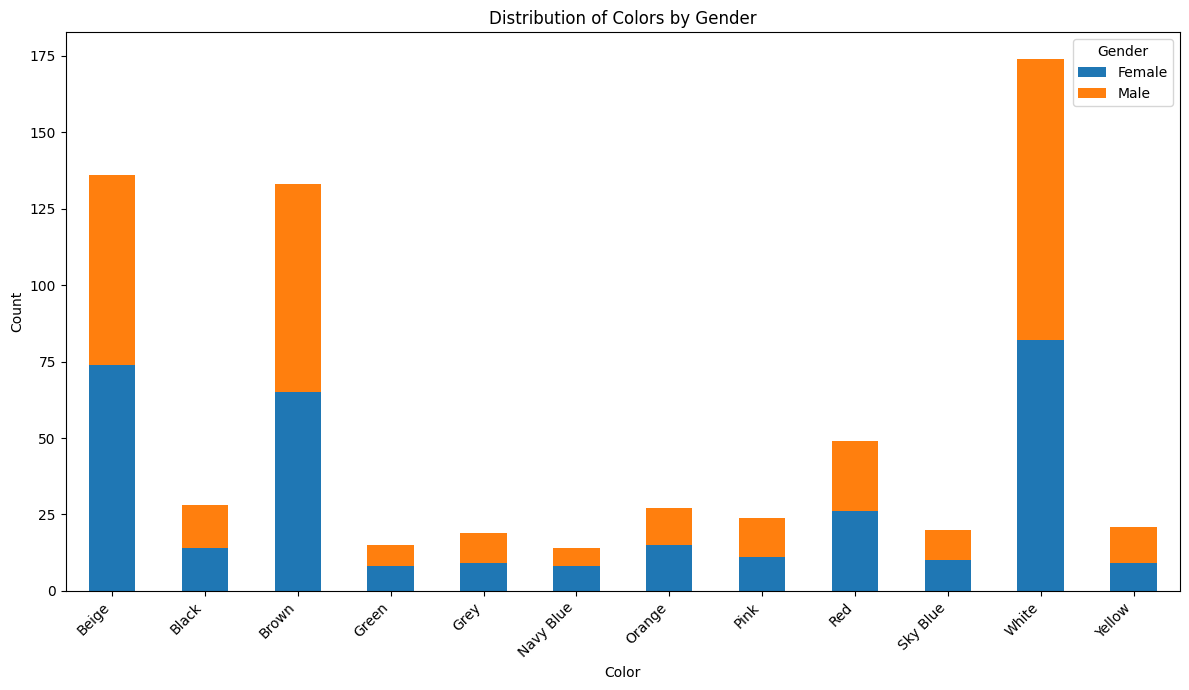

In [64]:
import matplotlib.pyplot as plt

# Plotting the distribution as a stacked bar chart
table.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Distribution of Colors by Gender')
plt.xlabel('Color')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [66]:
print(f"P-value for the association between color and gender: {pvalue:.4f}")

if pvalue < 0.05:
    print("Since the p-value is less than 0.05, there is a statistically significant association between color and gender.")
else:
    print("Since the p-value is greater than 0.05, there is no statistically significant association between color and gender.")
print("\nThis suggests that the distribution of product colors does not significantly differ across genders.")

P-value for the association between color and gender: 0.9876
Since the p-value is greater than 0.05, there is no statistically significant association between color and gender.

This suggests that the distribution of product colors does not significantly differ across genders.
